# Project 8 - ANN

## Libraries

In [1]:
import os
import random
import numpy as np
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Question 1.
Download the “Dog Breed Image Dataset” from Kaggle and upload it to Google Colab (without unzipping it). It should be named “archive.zip”

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Question 2.
Run the command “!unzip archive.zip” to unzip the data.


In [3]:
!unzip /content/drive/MyDrive/Colab\ Notebooks/datasets/dog_breeds.zip

Archive:  /content/drive/MyDrive/Colab Notebooks/datasets/dog_breeds.zip
  inflating: dataset/Beagle/Beagle_1.jpg  
  inflating: dataset/Beagle/Beagle_10.jpg  
  inflating: dataset/Beagle/Beagle_100.jpg  
  inflating: dataset/Beagle/Beagle_11.jpg  
  inflating: dataset/Beagle/Beagle_12.jpg  
  inflating: dataset/Beagle/Beagle_13.jpg  
  inflating: dataset/Beagle/Beagle_14.jpg  
  inflating: dataset/Beagle/Beagle_15.jpg  
  inflating: dataset/Beagle/Beagle_16.jpg  
  inflating: dataset/Beagle/Beagle_17.jpg  
  inflating: dataset/Beagle/Beagle_18.jpg  
  inflating: dataset/Beagle/Beagle_19.jpg  
  inflating: dataset/Beagle/Beagle_2.jpg  
  inflating: dataset/Beagle/Beagle_20.jpg  
  inflating: dataset/Beagle/Beagle_21.jpg  
  inflating: dataset/Beagle/Beagle_22.jpg  
  inflating: dataset/Beagle/Beagle_23.jpg  
  inflating: dataset/Beagle/Beagle_24.jpg  
  inflating: dataset/Beagle/Beagle_25.jpg  
  inflating: dataset/Beagle/Beagle_26.jpg  
  inflating: dataset/Beagle/Beagle_27.jpg  
  in

## Question 3.
Then, load the images into numpy arrays: Each image is loaded as RGB and converted to a 64x64 image (for speed and memory reasons)! The targets are converted to


In [78]:
dataset_path = 'dataset'
dog_image = []
dog_label = []

# For loop in every breed and after get every image storing and the label at the same time
for dog_breed in os.listdir(dataset_path):
  full_path = os.path.join(dataset_path, dog_breed) #Create full path to get image for every bread
  for dog_img_path in os.listdir(full_path):
    # Read image using PIL
    dog = Image.open(os.path.join(full_path, dog_img_path))
    dog = dog.resize((64,64)) # Resizing to 64*64 (Due to RAM limitation)
    dog = np.array(dog) # Convert image to np array
    dog_image.append(dog)
    dog_label.append(dog_breed)

# Convert list to np array
dog_image = np.array(dog_image)
dog_label = np.array(dog_label)

print(dog_image.shape)
print(dog_label.shape)


(967, 64, 64, 3)
(967,)


In [79]:
dog_image.shape[1:]

(64, 64, 3)

## Question 4.
Create the following MLP and analyze its architecture (layer type, number of inputs and outputs per layer, and activation function of the layers).


### Preprocessing before initialize the MLP
1) Set a random seed:
  - **tf.random.set_seed(0):** Sets the global random seed.
  - **np.random.seed(0):** makes the random numbers predictable
  - **random.seed(0):** seeding a pseudo-random number generator gives it its first "previous" value

  *Summary of all: if you provide the same seed twice, you get the same sequence of numbers twice.*

2) Image/label normilization (divide with max image(pixel) number 255 is the max value and one hot encoding labels)
3) Train-test split (30% test set - 70% training set)


In [80]:
# ================ 1. Set up seed ================
seed = 0

tf.random.set_seed(seed=seed)
np.random.seed(seed=seed)
random.seed(seed)

In [81]:
# ================ 2. Image/Labels Normilization ================

# Image nomrilization
dog_image = dog_image/255

# Get labels and enumerate them in dict (key name of the dog and value a number from 0-9)
class_names = sorted(set(dog_label))
dog_encoding = {name: idx for idx, name in enumerate(class_names)}
y_int = np.array([dog_encoding[label] for label in dog_label])
dog_label = np.eye(len(class_names))[y_int]
dog_label.shape

(967, 10)

In [82]:
# ================ 2. Train-Test split ================
X_train, X_test, y_train, y_test = train_test_split(dog_image, dog_label, test_size=0.3, stratify=dog_label, random_state=seed)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (676, 64, 64, 3)
Shape of y_train: (676, 10)
Shape of X_test: (291, 64, 64, 3)
Shape of y_test: (291, 10)


### Explanation of MLP
Use Sequential to create the architecture:
- Input(64 * 64 * 3 -> the shape of the image)
- Flatten: Flattens the input into 1D array
- Dense is the layer of the perceptron. For the first and second layer we use:
  - 128 units which are the dimensionality of the output space.
  - As activation function the relu function
  - Use bias is whether the layer uses a bias vector or not (Set it to true)
- The third layer:
  - units equal to the number of classes since it is the last layer of prediction("softmax")
  - The activation is the softmax (the last layer which will give the final results)
  - Again use bias is whether the layer uses a bias vector or not (Set it to true)


In [83]:
input_size = X_train.shape[1:]
output_size = len(class_names)

In [84]:
mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_size),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation='relu', use_bias=True),
    tf.keras.layers.Dense(units=128, activation='relu', use_bias=True),
    tf.keras.layers.Dense(units=output_size, activation='softmax', use_bias=True)
], name='MLP')
mlp.summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,590,794 (6.07 MB)

 Trainable params: 1,590,794 (6.07 MB)

 Non-trainable params: 0 (0.00 B)

## Question 5.
Train the model using the following:
- Optimizer: Adam
- Learning Rate: 0.001
- Loss Function: Categorical Cross-Entropy
- Batch Size: 32
- Epochs: 30


In [89]:
# Initialize optimizer with learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001)
# Initialize loss function (Categorical Cross-Entropy)
loss = tf.keras.losses.CategoricalCrossentropy()
# Initialize batch size
batch_size = 32
# Initialize epochs
epochs = 30

## Question 6.
Display the loss history and accuracy history for the train and test data.

**Final results:**

Train accuracy: 0.9923

Train loss: 0.0330

Validation accuracy: 0.9931

Validation loss: 0.0770


In [11]:
mlp.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
history = mlp.fit(
    x=X_train,
    y=y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_test, y_test)
)


Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.0922 - loss: 3.8427 - val_accuracy: 0.1512 - val_loss: 2.6409
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2218 - loss: 2.2985 - val_accuracy: 0.2268 - val_loss: 2.0228
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3164 - loss: 1.9506 - val_accuracy: 0.3402 - val_loss: 1.7972
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4880 - loss: 1.6265 - val_accuracy: 0.3952 - val_loss: 1.6502
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5230 - loss: 1.4586 - val_accuracy: 0.5430 - val_loss: 1.4481
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6609 - loss: 1.2200 - val_accuracy: 0.5498 - val_loss: 1.3530
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6996 - loss: 1.0206 - val_accuracy: 0.6701 - val_loss: 1.1643
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8153 - loss: 0.8122 - val_accuracy: 0.6701 - v

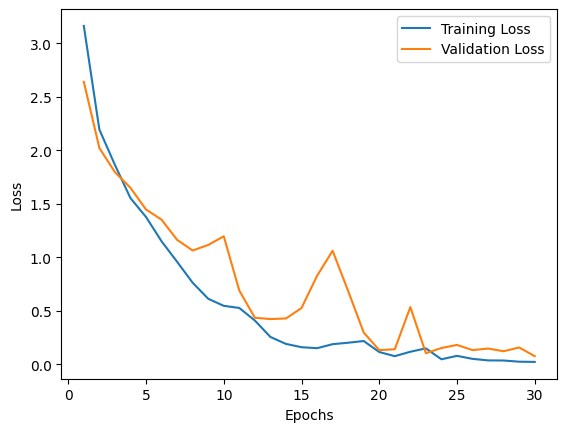

In [12]:
# Training loss line
loss_values = history.history['loss']
epochs_ = range(1, len(loss_values)+1)
plt.plot(epochs_, loss_values, label='Training Loss')

# Test loss line
loss_values = history.history['val_loss']
epochs_ = range(1, len(loss_values)+1)
plt.plot(epochs_, loss_values, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Question 7.
Repeat questions 6 to 8 using the CNN below. Then explain which model is better.

Explaning CNN:

1) Input: the image (same shape as before in MLP)

Now we use and Convolutional 2D layes which means: This layer creates a convolution kernel that is convolved with the layer
input over a 2D spatial (or temporal) dimension

<img src="https://miro.medium.com/v2/resize:fit:4800/format:webp/1*o8O7owMwiF4Ull9NE-uWQw.gif" width="500">

*Source: [Medium](https://medium.com/data-science/conv2d-to-finally-understand-what-happens-in-the-forward-pass-1bbaafb0b148)*

2) Conv2D first layer:
- filters: the dimension of the output space (Set to 32)
- kernel_size: specifying the size of the convolution window (Set to 3*3)
- strides: the stride length of the convolution (two boxes per kernel move)
- activation: same as before this is the activation function set to relu
- use_bias: same as before

3) After this layer add dropout to 20% to prevent overfitting
4) Again the same Convolutional 2D layer with stride set to one (more details)
5) Flatten the image (make image 1D array)
6) Create two Dense layers:
      - First layer uses 128 units and relu activation function
      - Second layer is the softmax for the output prediction






In [12]:
cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_size),
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, strides=2, activation='relu', use_bias=True),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, strides=1, activation='relu', use_bias=True),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation='relu', use_bias=True),
    tf.keras.layers.Dense(units=output_size, activation='softmax', use_bias=True)
], name='CNN')
cnn.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 31, 31, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 26912)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,444,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,456,298 (13.18 MB)

 Trainable params: 3,456,298 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

### Final Resutls  
Train accuracy: 1.0000

Train loss: 1.8245e-04

Test val_accuracy: 0.9931

Test val_loss: 0.1153


Looking at the results both models had great results for training and test set. In training set CNN fit much faster and found the patterns to recognize the differences between images much faster than Perceptron. Perceptron by looking at the training and test line is not so stable and have some spikes, on the other hand CNN lines are smooth with no spikes at all which means that CNN has greater adaptability. Since both models had great results I will choose CNN as the best model because of the better adaptability and no spikes which means it more stable for tasks like this. It is important to mention that CNN is overfitting since training accuracy is 100% with training loss 0.0001 BUT test loss is 0.1 which is not normal meaning that model overfits fitting in training set not able to generalize well.

In [14]:
cnn.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
cnn_history = cnn.fit(
    x=X_train,
    y=y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_test, y_test)
)


Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.1506 - loss: 2.4182 - val_accuracy: 0.3093 - val_loss: 2.0290
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.4082 - loss: 1.8410 - val_accuracy: 0.5704 - val_loss: 1.3525
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.7143 - loss: 0.9779 - val_accuracy: 0.7423 - val_loss: 0.7990
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.8891 - loss: 0.4508 - val_accuracy: 0.9588 - val_loss: 0.2394
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.9841 - loss: 0.1393 - val_accuracy: 0.9622 - val_loss: 0.1576
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.9850 - loss: 0.0767 - val_accuracy: 0.9931 - val_loss: 0.0756
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 1.0000 - loss: 0.0158 - val_accuracy: 0.9931 - val_loss: 0.0739
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 1.0000 - loss: 0.0061 - val_accuracy: 0.

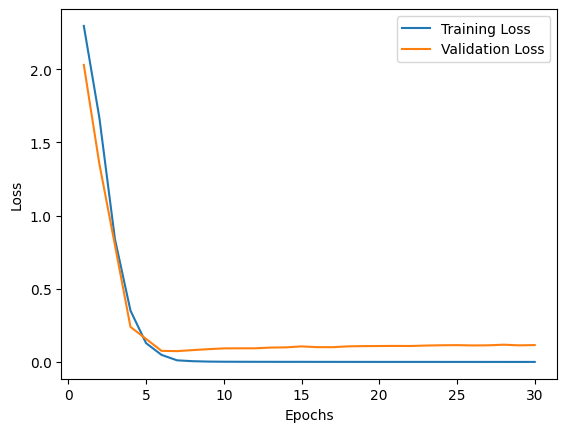

In [15]:
# Training loss line
loss_values = cnn_history.history['loss']
epochs_ = range(1, len(loss_values)+1)
plt.plot(epochs_, loss_values, label='Training Loss')

# Test loss line
loss_values = cnn_history.history['val_loss']
epochs_ = range(1, len(loss_values)+1)
plt.plot(epochs_, loss_values, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Question 8.
Apply any other technique you want to improve the accuracy of the CNN! You can try Standard Scaling, Batch Normalization, Hyperparameter Tuning, etc.

I try:

- Data augmentation
- Different architecture (Adding max pooling layers)
- Change dropout value
- Change batch size value
- Change epoch
- Use differnt filters (found a practise to upscale the value in power of 2)

*Nothing works since results are very good in the cnn training. The  one thing which is working is the code I tried and got better validation loss*

In [136]:
# Initialize optimizer with learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001)
# Initialize loss function (Categorical Cross-Entropy)
loss = tf.keras.losses.CategoricalCrossentropy()
# Initialize batch size
batch_size = 32
# Initialize epochs
epochs = 30

In [137]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_size),

    # data_augmentation,

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', use_bias=True),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', use_bias=True),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', use_bias=True),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(units=output_size, activation='softmax', use_bias=True)
])

In [138]:
cnn.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
cnn_history = cnn.fit(
    x=X_train,
    y=y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_test, y_test)
)


Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 210ms/step - accuracy: 0.1290 - loss: 2.3457 - val_accuracy: 0.3849 - val_loss: 2.2176
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2896 - loss: 2.1412 - val_accuracy: 0.3677 - val_loss: 1.6862
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4756 - loss: 1.5747 - val_accuracy: 0.6804 - val_loss: 1.0762
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6588 - loss: 0.9405 - val_accuracy: 0.8351 - val_loss: 0.5928
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8809 - loss: 0.4697 - val_accuracy: 0.9141 - val_loss: 0.2946
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9583 - loss: 0.2024 - val_accuracy: 0.9381 - val_loss: 0.1704
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9832 - loss: 0.0880 - val_accuracy: 0.9691 - val_loss: 0.1246
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9873 - loss: 0.0565 - val_accuracy: 0.9931 - 

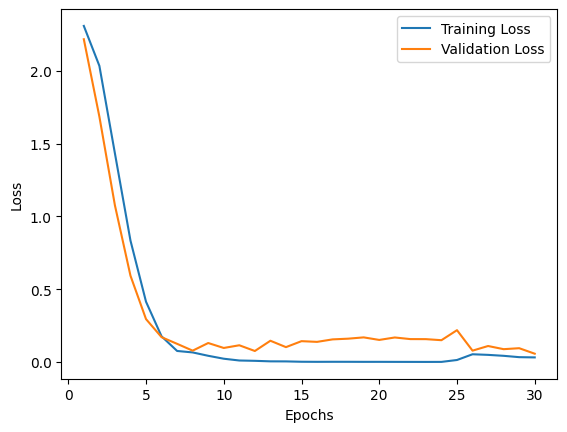

In [139]:
# Training loss line
loss_values = cnn_history.history['loss']
epochs_ = range(1, len(loss_values)+1)
plt.plot(epochs_, loss_values, label='Training Loss')

# Test loss line
loss_values = cnn_history.history['val_loss']
epochs_ = range(1, len(loss_values)+1)
plt.plot(epochs_, loss_values, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()